In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
# --- 1. DATA LOADING & PREPROCESSING ---
# Loading the provided Mumbai rainfall dataset (1901-2021)
df = pd.read_csv('mumbai-monthly-rains.csv')

In [3]:
# Reshaping data from wide to long format to allow the model to learn monthly patterns
data_melted = df.melt(id_vars='Year', value_vars=['Jan', 'Feb', 'Mar', 'April', 'May', 'June', 
                                                 'July', 'Aug', 'Sept', 'Oct', 'Nov', 'Dec'],
                      var_name='Month', value_name='Rainfall')

In [4]:
# Mapping month names to numerical values for machine learning compatibility
month_map = {'Jan': 1, 'Feb': 2, 'Mar': 3, 'April': 4, 'May': 5, 'June': 6,
             'July': 7, 'Aug': 8, 'Sept': 9, 'Oct': 10, 'Nov': 11, 'Dec': 12}
data_melted['Month_Num'] = data_melted['Month'].map(month_map)

In [5]:
# Defining Features (Year and Month) and Target (Rainfall)
X = data_melted[['Year', 'Month_Num']]
y = data_melted['Rainfall']

In [6]:
# Splitting data: 80% for training and 20% for testing to evaluate performance
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
# --- 2. MODEL COMPARISON ---
# We compare a simple Linear Regression (Baseline) against a Random Forest (Complex)
# to justify the choice of a more sophisticated algorithm.

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)
    results[name] = {"RMSE": rmse, "R2": r2}

In [8]:
# Displaying comparison results
print("--- Model Comparison Results ---")
for name, metrics in results.items():
    print(f"{name}: RMSE = {metrics['RMSE']:.2f}, R-squared = {metrics['R2']:.2f}")

--- Model Comparison Results ---
Linear Regression: RMSE = 294.77, R-squared = 0.03
Random Forest: RMSE = 177.69, R-squared = 0.65


In [9]:
# --- 3. DOCUMENTATION: WHY THESE FEATURES? ---
"""
Feature Selection Rationale:
1. 'Year': Captures long-term climatic shifts or trends over the century.
2. 'Month_Num': Essential because Mumbai's rainfall is highly seasonal (Monsoon-driven).
   The model needs to distinguish between a dry January and a peak-rain July.
"""

"\nFeature Selection Rationale:\n1. 'Year': Captures long-term climatic shifts or trends over the century.\n2. 'Month_Num': Essential because Mumbai's rainfall is highly seasonal (Monsoon-driven).\n   The model needs to distinguish between a dry January and a peak-rain July.\n"

In [10]:
# --- 4. FORECASTING FOR THE REMAINDER OF 2026 ---
# As per project requirements, we generate a forecast for the upcoming months.
# We will use the Random Forest model as it typically handles non-linear weather patterns better.

best_model = models["Random Forest"]
current_month = 4 # April 2026
future_months_2026 = pd.DataFrame({
    'Year': [2026] * (12 - current_month),
    'Month_Num': range(current_month + 1, 13)
})

forecast_2026 = best_model.predict(future_months_2026)

In [11]:
# Mapping numbers back to names for the report
month_names = ['Jan', 'Feb', 'Mar', 'April', 'May', 'June', 'July', 'Aug', 'Sept', 'Oct', 'Nov', 'Dec']
forecast_display = pd.DataFrame({
    'Month': [month_names[m-1] for m in range(current_month + 1, 13)],
    'Forecasted Rainfall (mm)': forecast_2026
})

print("\n--- Mumbai Rainfall Forecast: May 2026 - Dec 2026 ---")
print(forecast_display)


--- Mumbai Rainfall Forecast: May 2026 - Dec 2026 ---
  Month  Forecasted Rainfall (mm)
0   May                133.675897
1  June                729.342523
2  July               1192.168918
3   Aug                616.910276
4  Sept                507.914002
5   Oct                145.724994
6   Nov                 18.995940
7   Dec                 11.032412


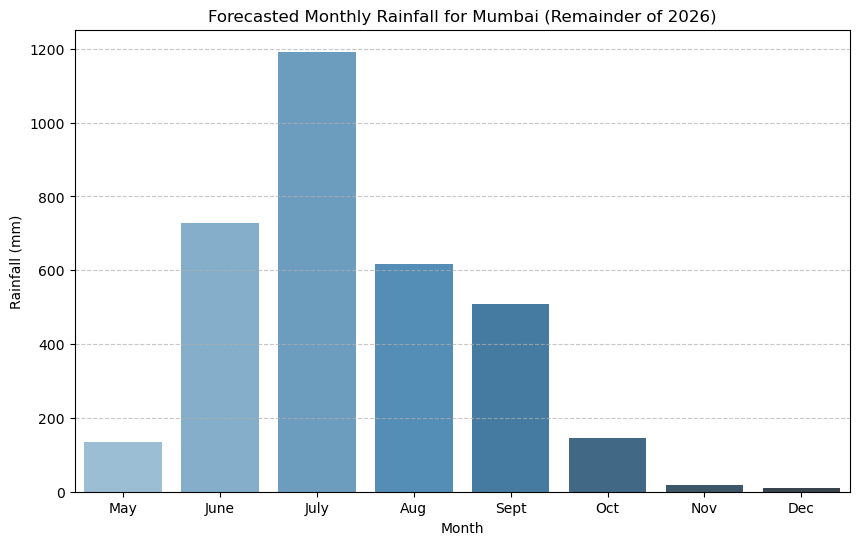

In [12]:
# --- 5. VISUALIZING THE FORECAST ---
plt.figure(figsize=(10, 6))
sns.barplot(data=forecast_display, x='Month', y='Forecasted Rainfall (mm)', palette='Blues_d')
plt.title('Forecasted Monthly Rainfall for Mumbai (Remainder of 2026)')
plt.ylabel('Rainfall (mm)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

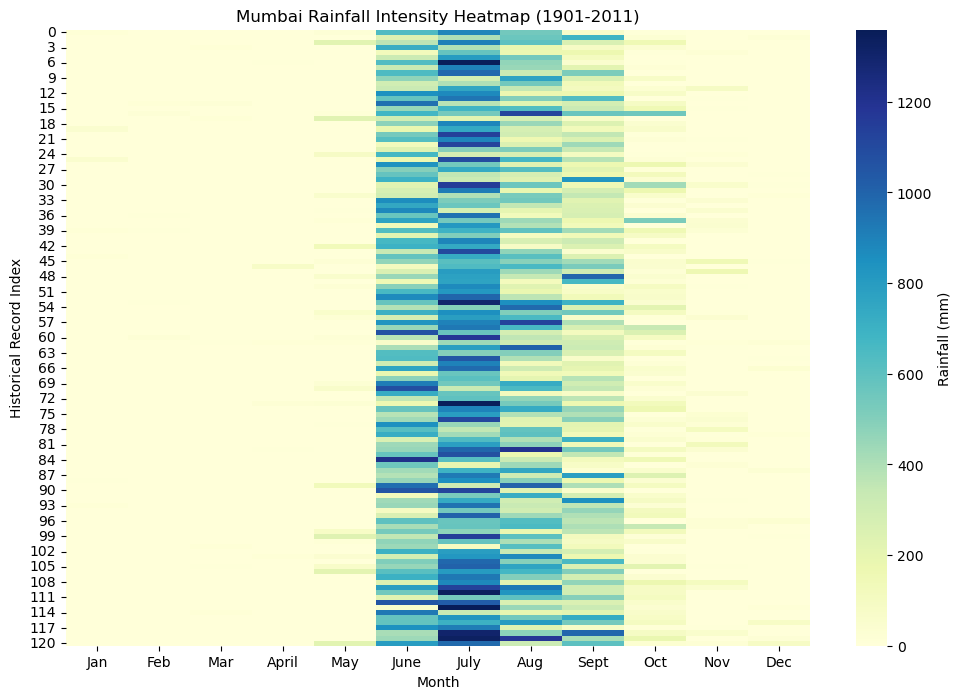

C:\Users\Partha\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


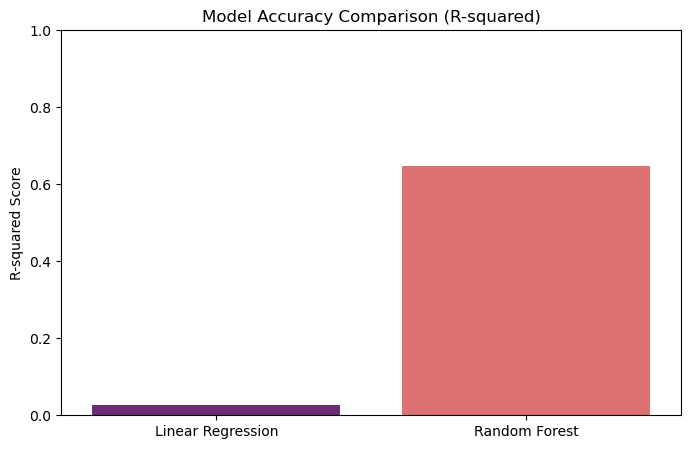

C:\Users\Partha\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Partha\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


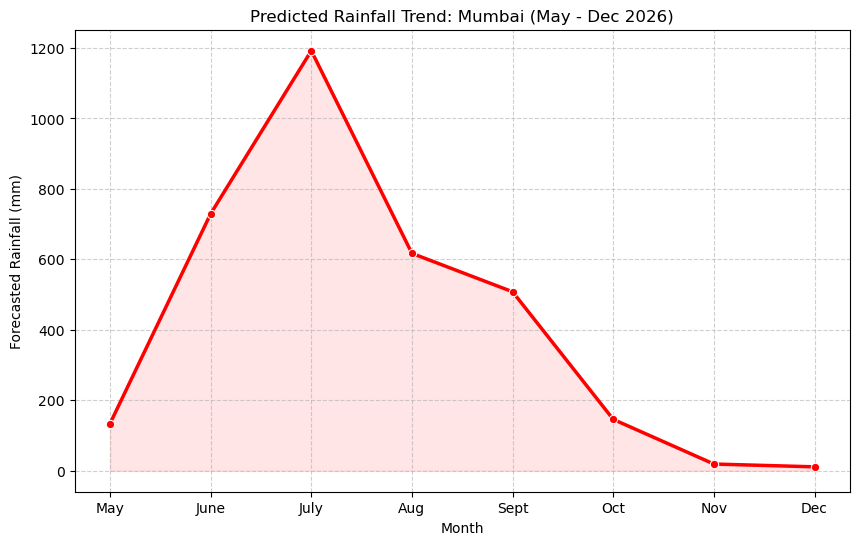

Forecasting Complete. Please copy these charts into your final report.


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# --- 1. DATA LOADING & PREPROCESSING ---
df = pd.read_csv('mumbai-monthly-rains.csv')

# --- VISUALIZATION 1: SEASONALITY HEATMAP (For Historical Analysis) ---
# This shows the "Dry Window" vs "Monsoon Peak" across decades
plt.figure(figsize=(12, 8))
sns.heatmap(df.iloc[:, 1:13], cmap='YlGnBu', cbar_kws={'label': 'Rainfall (mm)'})
plt.title('Mumbai Rainfall Intensity Heatmap (1901-2011)')
plt.xlabel('Month')
plt.ylabel('Historical Record Index')
plt.show()

# Reshaping data for Machine Learning
data_melted = df.melt(id_vars='Year', value_vars=['Jan', 'Feb', 'Mar', 'April', 'May', 'June', 
                                                 'July', 'Aug', 'Sept', 'Oct', 'Nov', 'Dec'],
                      var_name='Month', value_name='Rainfall')

month_map = {'Jan': 1, 'Feb': 2, 'Mar': 3, 'April': 4, 'May': 5, 'June': 6,
             'July': 7, 'Aug': 8, 'Sept': 9, 'Oct': 10, 'Nov': 11, 'Dec': 12}
data_melted['Month_Num'] = data_melted['Month'].map(month_map)

X = data_melted[['Year', 'Month_Num']]
y = data_melted['Rainfall']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- 2. MODEL COMPARISON ---
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42)
}

model_names = []
r2_scores = []

for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    r2 = r2_score(y_test, predictions)
    model_names.append(name)
    r2_scores.append(r2)

# --- VISUALIZATION 2: MODEL PERFORMANCE (Validation) ---
plt.figure(figsize=(8, 5))
sns.barplot(x=model_names, y=r2_scores, palette='magma')
plt.title('Model Accuracy Comparison (R-squared)')
plt.ylabel('R-squared Score')
plt.ylim(0, 1)
plt.show()

# --- 3. 2026 FORECASTING ---
best_model = models["Random Forest"]
# Forecasting for the remainder of 2026 (May to December)
future_months_2026 = pd.DataFrame({
    'Year': [2026] * 8,
    'Month_Num': range(5, 13)
})

forecast_2026 = best_model.predict(future_months_2026)
month_names = ['May', 'June', 'July', 'Aug', 'Sept', 'Oct', 'Nov', 'Dec']
forecast_display = pd.DataFrame({'Month': month_names, 'Forecast': forecast_2026})

# --- VISUALIZATION 3: 2026 FORECAST TREND (Future Planning) ---
plt.figure(figsize=(10, 6))
sns.lineplot(data=forecast_display, x='Month', y='Forecast', marker='o', color='red', linewidth=2.5)
plt.fill_between(forecast_display['Month'], forecast_display['Forecast'], color="red", alpha=0.1)
plt.title('Predicted Rainfall Trend: Mumbai (May - Dec 2026)')
plt.ylabel('Forecasted Rainfall (mm)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print("Forecasting Complete. Please copy these charts into your final report.")